SIT - 307 - Machine Learning - 8.2D 

Name - Gurnoor Singh 

Student ID - s223955119 

1. Melbourne Housing Data Collection 

For the dataset , housing data from three suburbs in Western Victoria i.e. Williams Landing, Tarneit and Point Cook was collected with 11 Features and Sold_price as target variable. 

2. Pre-Processing and Exploratory data analysis

Dataset was loaded with 150 entries and 12 columns. Sold price was stored as string with '$' and commas. Study column as 'Yes/No' strings, sold_date as excel serial numbers and some apartments, units and townhouses had incorrect land sizes. 

Encoding and Creation of New Features 

In [5]:
#importing the required libraries 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler 

#loading the dataset 
df = pd.read_excel("C:/Users/gurno/OneDrive/Documents/TRIMESTER_1_2026/SIT307-Machine Learning/SIT307-8.2D/SIT307-8.2DTASK.xlsx")
df.head()

print(df.shape)
df.describe()

#cleaning column names 
df.columns = df.columns.str.strip().str.strip().str.lower().str.replace(' ','_')
print(df.columns.tolist())

#fixing sold price column. 
df['sold_price_aud'] = df['sold_price_aud'].str.replace(r'[\$,]','',regex=True).astype(float)

#encoding study column 
df['study'] = df['study'].str.strip().map({'Yes' : 1, 'No' : 0})

#printing sold date column
df['sold_date'] = pd.to_datetime(df['sold_date'])
df['sold_year'] = df['sold_date'].dt.year
df['sold_month'] = df['sold_date'].dt.month

#fixing dodgy landsizes 
non_house = ['apartment','unit','townhouse']

mask = (df['propert_type'].str.strip().str.lower().isin(non_house)) & (df['land_size_m2'] > 1000)

df.loc[mask,'land_size_m2'] = np.nan

#impute with median per property type and subsurb 
df['land_size_m2'] = df.groupby(['suburb','propert_type'])['land_size_m2'].transform(
    lambda x : x.fillna(x.median())
)


print(df['sold_price_aud'].dtype)
print(df['study'].dtype)

(150, 12)
['suburb', 'propert_type', 'num_bedrooms', 'num_bathrooms', 'land_size_m2', 'distanceto_cbd_km', 'sold_date', 'car_spaces', 'schools_nearby', 'study', 'sold_price_aud', 'agency']
float64
int64


Column names standardised to lowercase with underscores. Sold price converted to float and study encoded to binary datatype. Sold date converted to datetime with year and month extracted. Dodgy land sizes for non-house properties replaced with median of same property type and suburb.

Standardisation of Numerical Features

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['num_bedrooms','num_bathrooms','distanceto_cbd_km','car_spaces','schools_nearby']
df[num_cols] = scaler.fit_transform(df[num_cols])

Visualisations for Housing Prices 

Price(Sold Price) Distribution 

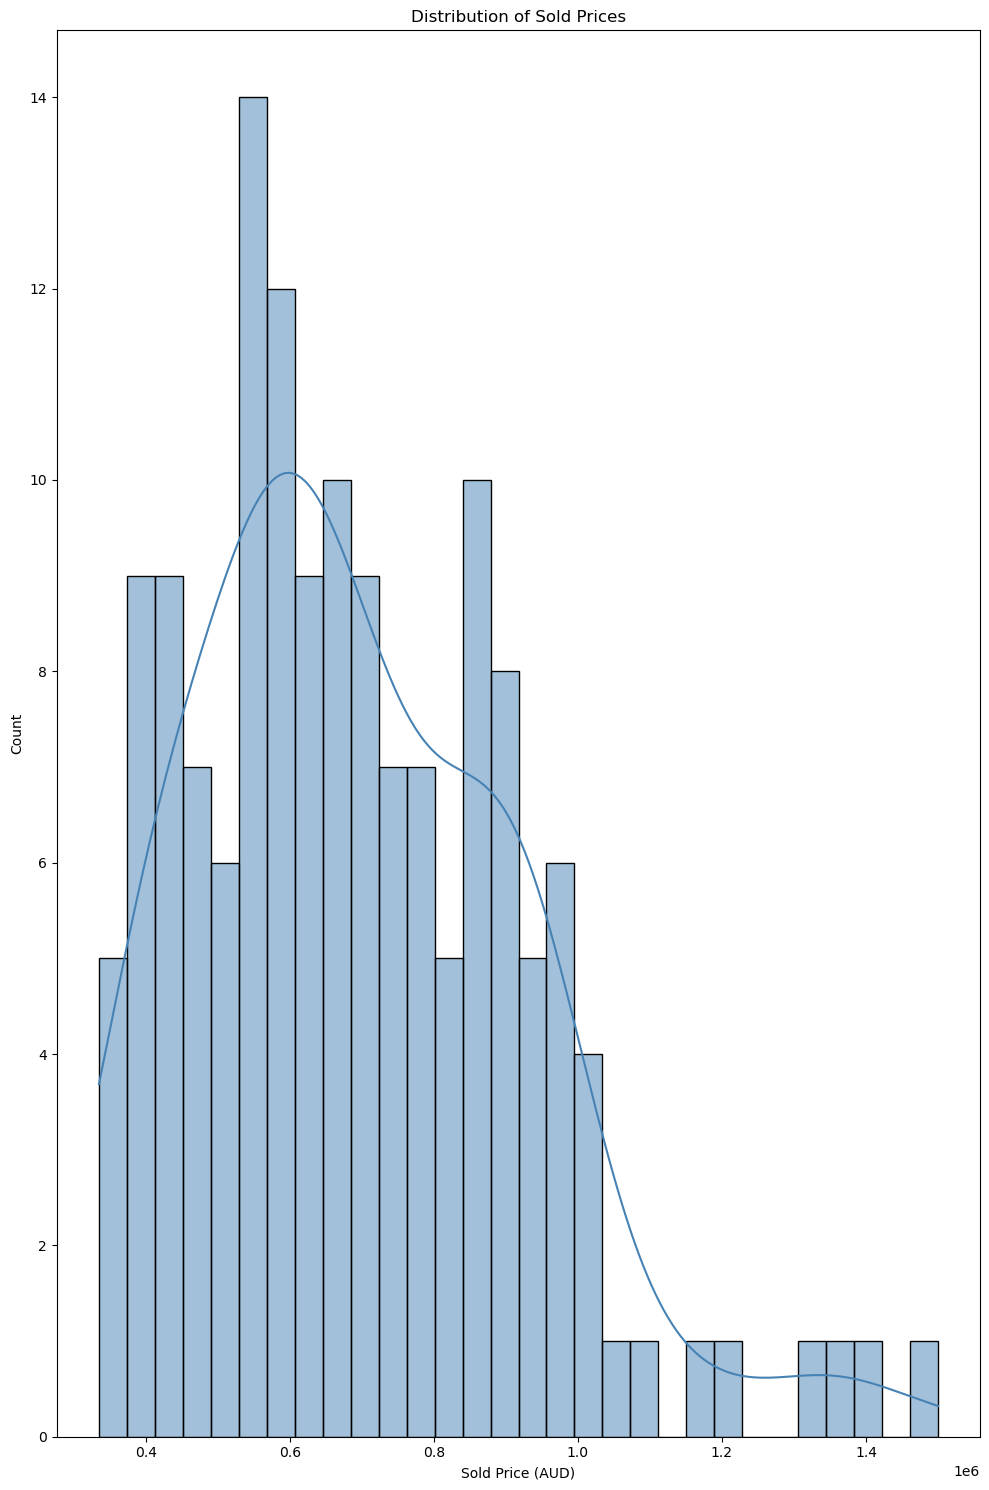

In [10]:
#price distribution 
plt.figure(figsize=(10,15))
sns.histplot(df['sold_price_aud'],bins=30,kde=True,color='steelblue')
plt.title('Distribution of Sold Prices')
plt.xlabel('Sold Price (AUD)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Visualisation of Price by Suburb 

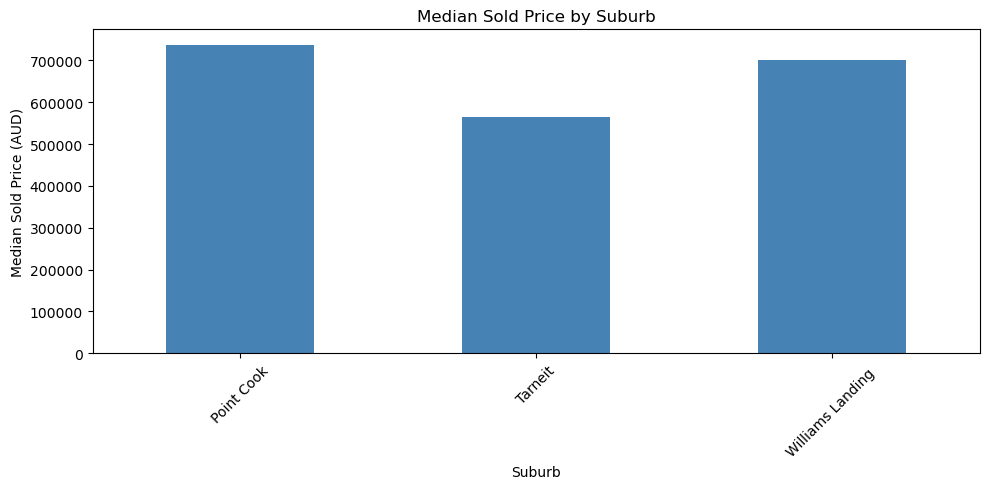

In [12]:
plt.figure(figsize = (10,5))
df.groupby('suburb')['sold_price_aud'].median().plot(kind='bar',color='steelblue')
plt.title('Median Sold Price by Suburb')
plt.xlabel('Suburb')
plt.ylabel('Median Sold Price (AUD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Visualisation of price by property

<Figure size 1200x600 with 0 Axes>

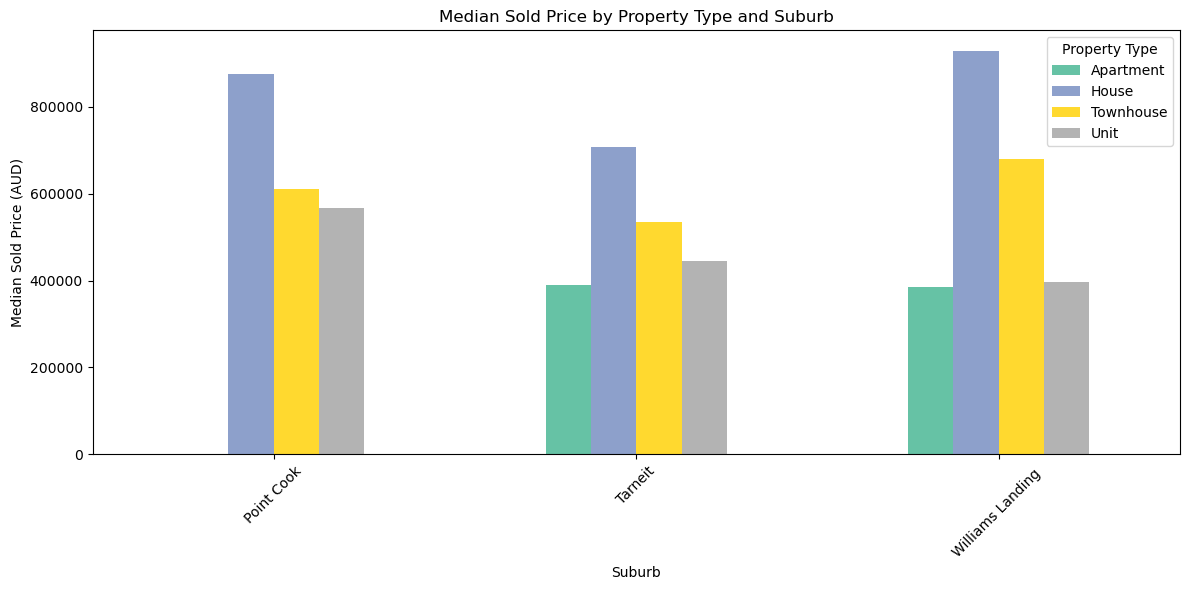

In [14]:
df['propert_type'] = df['propert_type'].str.strip()
plt.figure(figsize=(12,6))
df.groupby(['suburb','propert_type'])['sold_price_aud'].median().unstack().plot(kind='bar',figsize=(12,6),colormap='Set2')
plt.title('Median Sold Price by Property Type and Suburb')
plt.xlabel('Suburb')
plt.ylabel('Median Sold Price (AUD)')
plt.xticks(rotation=45)
plt.legend(title='Property Type')
plt.tight_layout()
plt.show()

Feature Correlation

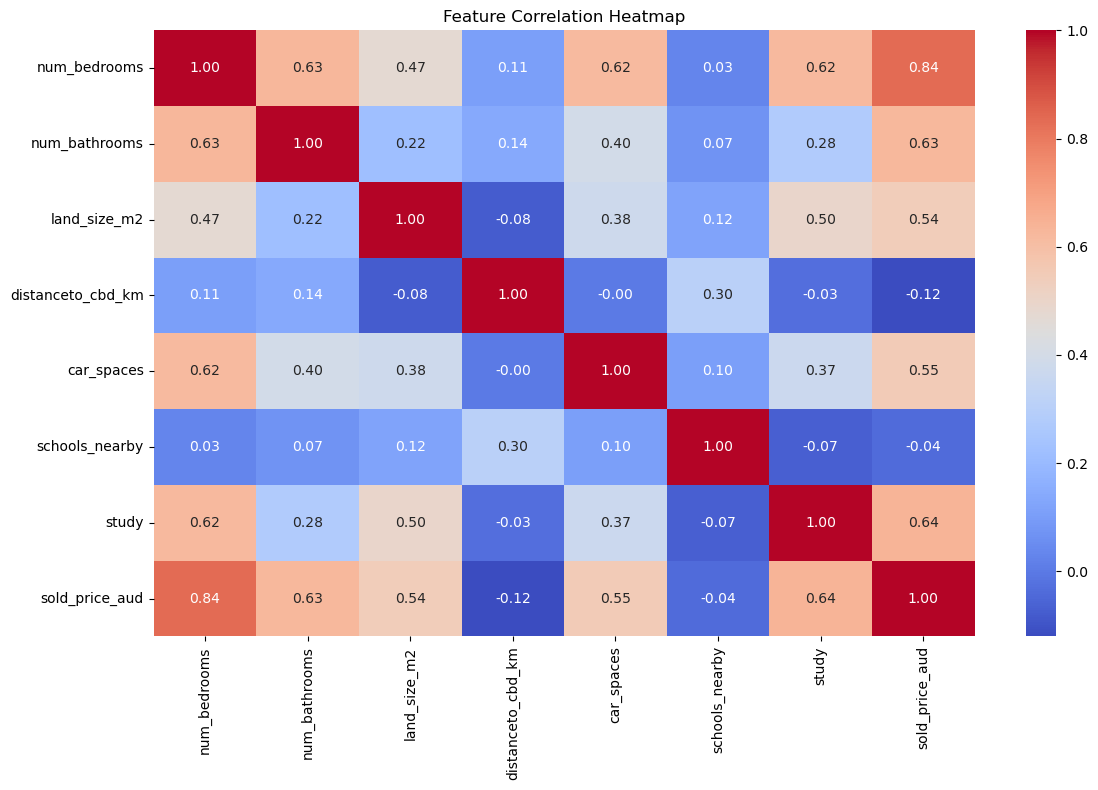

In [16]:
num_cols = ['num_bedrooms','num_bathrooms','land_size_m2','distanceto_cbd_km','car_spaces','schools_nearby','study','sold_price_aud']
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

Outlier Detection 

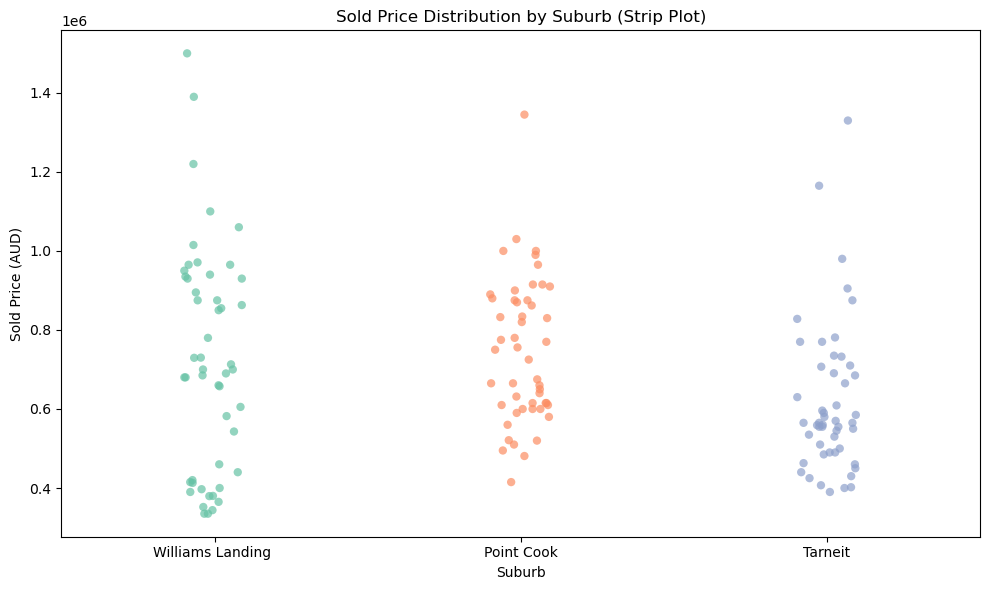

In [18]:
plt.figure(figsize=(10,6))
sns.stripplot(x='suburb',y='sold_price_aud',data=df,hue='suburb',jitter=True,palette='Set2',alpha=0.7,size=6,legend=False)
plt.title('Sold Price Distribution by Suburb (Strip Plot)')
plt.xlabel('Suburb')
plt.ylabel('Sold Price (AUD)')
plt.tight_layout()
plt.show()

Price Trend Over Time by Suburb

In [20]:
#fixing wrong dates before visualisation  
df.loc[df['sold_year'] == 2006, 'sold_date'] = df.loc[df['sold_year'] == 2006, 'sold_date'].apply(lambda x : x.replace(year=2026))
df.loc[df['sold_year'] == 2006, 'sold_year'] = 2026

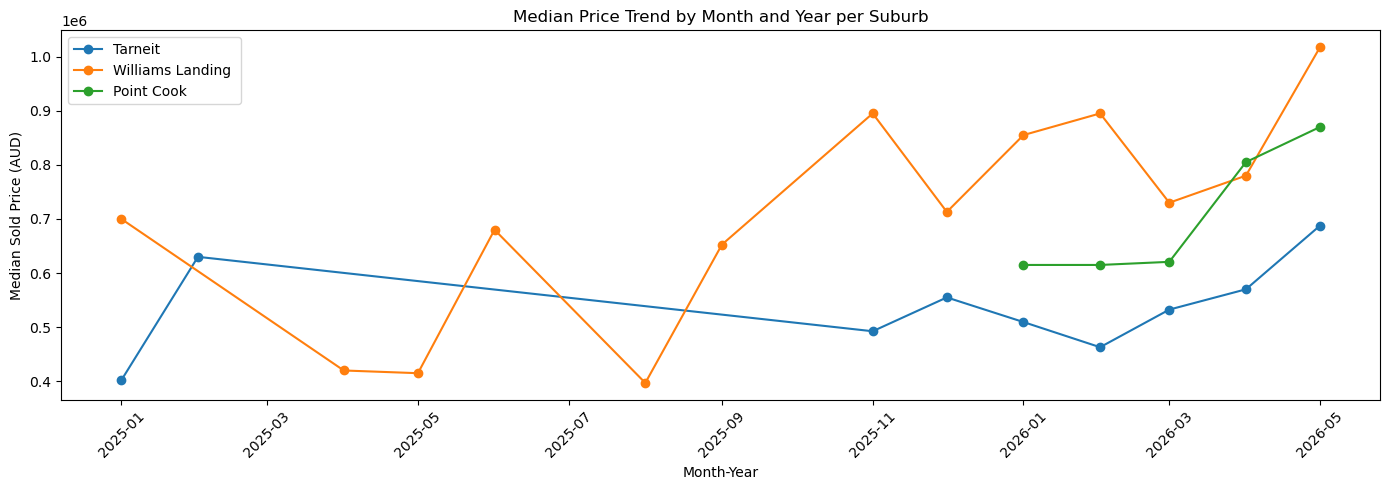

In [21]:
df_time = df.groupby(['sold_year','sold_month','suburb'])['sold_price_aud'].median().reset_index()
df_time['date'] = pd.to_datetime(df_time['sold_year'].astype(str) + '-' + df_time['sold_month'].astype(str) + '-01')

plt.figure(figsize=(14,5))
for suburb in df_time['suburb'].unique():
    sub = df_time[df_time['suburb']==suburb].sort_values('date')
    plt.plot(sub['date'],sub['sold_price_aud'],marker='o',label=suburb)
plt.title('Median Price Trend by Month and Year per Suburb')
plt.xlabel('Month-Year')
plt.ylabel('Median Sold Price (AUD)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

3. Model Development

In [23]:
#encoding data for modeling 
#encoding categorical columns 
df['propert_type'] = df['propert_type'].str.strip()
df['suburb'] = df['suburb'].str.strip()

df_model = pd.get_dummies(df,columns = ['propert_type','suburb'],drop_first=False)

#drop columns not needed for modeling 
df_model = df_model.drop(columns=['sold_date','agency'])

#define features and target 
X = df_model.drop(columns = ['sold_price_aud'])
Y = df_model['sold_price_aud']

print(X.shape)
print(X.columns.tolist())

(150, 16)
['num_bedrooms', 'num_bathrooms', 'land_size_m2', 'distanceto_cbd_km', 'car_spaces', 'schools_nearby', 'study', 'sold_year', 'sold_month', 'propert_type_Apartment', 'propert_type_House', 'propert_type_Townhouse', 'propert_type_Unit', 'suburb_Point Cook', 'suburb_Tarneit', 'suburb_Williams Landing']


Model 1 - Linear Regression

In [25]:
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np 

kf = KFold(n_splits=5,shuffle=True,random_state=42)
lr = LinearRegression()

mae_scores = []
rmse_scores = []
r2_scores = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index],X.iloc[test_index]
    Y_train,Y_test = Y.iloc[train_index],Y.iloc[test_index]

    lr.fit(X_train,Y_train)
    Y_pred = lr.predict(X_test)

    mae_scores.append(mean_absolute_error(Y_test,Y_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(Y_test,Y_pred)))
    r2_scores.append(r2_score(Y_test,Y_pred))

print("Linear Regression Results : ")
print(f"MAE : ${np.mean(mae_scores):,.0f}")
print(f"RMSE : ${np.mean(rmse_scores):,.0f}")
print(f"R squared : {np.mean(r2_scores):.4f}")

Linear Regression Results : 
MAE : $78,055
RMSE : $129,638
R squared : 0.4907


Model 2 - Random Forest 

In [27]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100,random_state=42)

mae_scores_rf = []
rmse_scores_rf = []
r2_scores_rf = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index],X.iloc[test_index]
    Y_train,Y_test = Y.iloc[train_index],Y.iloc[test_index]\

    rf.fit(X_train,Y_train)
    Y_pred = rf.predict(X_test)

    mae_scores_rf.append(mean_absolute_error(Y_test,Y_pred))
    rmse_scores_rf.append(np.sqrt(mean_squared_error(Y_test,Y_pred)))
    r2_scores_rf.append(r2_score(Y_test,Y_pred))

print("Random Forest Results : ")
print(f"MAE : ${np.mean(mae_scores_rf):,.0f}")
print(f"RMSE : ${np.mean(rmse_scores_rf):,.0f}")
print(f"R squared : {np.mean(r2_scores_rf):.4f}")

Random Forest Results : 
MAE : $48,703
RMSE : $71,913
R squared : 0.8802


Model 3 - XGBoost 

In [29]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100,random_state=42,verbosity=0)

mae_scores_xgb = []
rmse_scores_xgb = []
r2_scores_xgb = []

for train_index, test_index in kf.split(X) : 
    X_train,X_test = X.iloc[train_index],X.iloc[test_index]
    Y_train,Y_test = Y.iloc[train_index],Y.iloc[test_index]
    xgb.fit(X_train,Y_train)
    Y_pred = xgb.predict(X_test)
    mae_scores_xgb.append(mean_absolute_error(Y_test,Y_pred))
    rmse_scores_xgb.append(np.sqrt(mean_squared_error(Y_test,Y_pred)))
    r2_scores_xgb.append(r2_score(Y_test,Y_pred))

print("XGBoost Results : ")
print(f"MAE : ${np.mean(mae_scores_xgb):,.0f}")
print(f"RMSE : ${np.mean(rmse_scores_xgb):,.0f}")
print(f"R squared : {np.mean(r2_scores_xgb):.4f}")

XGBoost Results : 
MAE : $53,637
RMSE : $76,170
R squared : 0.8731


4. Feature Importance 

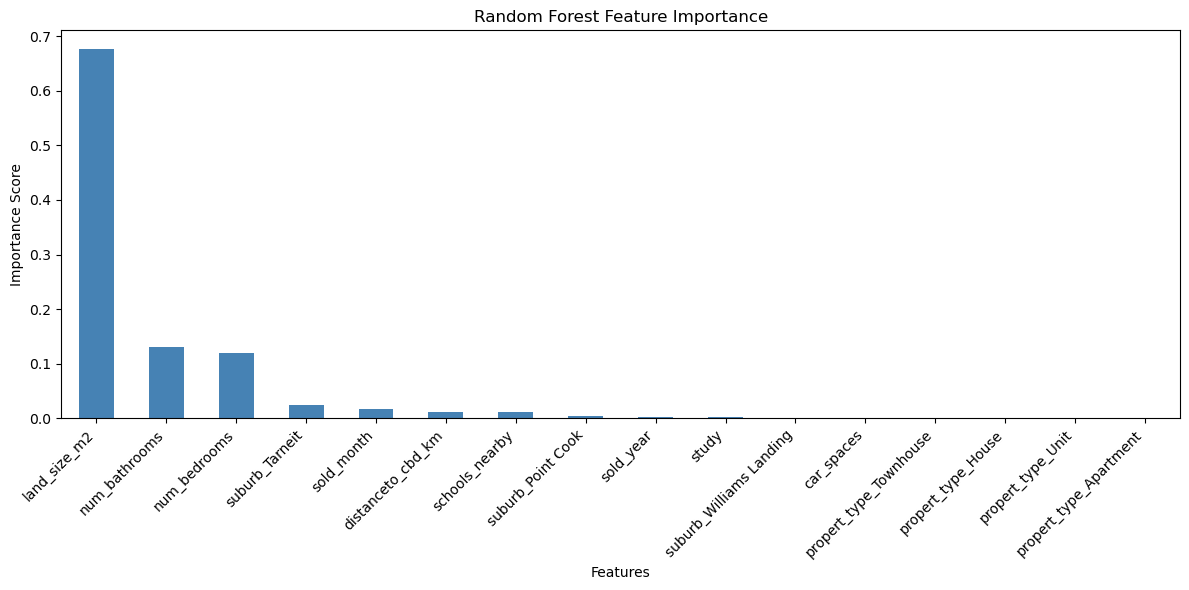

In [33]:
import matplotlib.pyplot as plt 
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_,index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(12,6))
feature_importance.plot(kind='bar',color='steelblue')
plt.title('Random Forest Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

5. Web App for price prediction 

In [44]:
!pip install gradio 

In [55]:
import gradio as gr

def predict_price(suburb,propert_type,bedrooms,bathrooms,land_size,distance_cbd,car_spaces,schools_nearby,study,sold_year,sold_month):
    
    input_data = pd.DataFrame({
        'num_bedrooms' : [bedrooms],
        'num_bathrooms' : [bathrooms],
        'land_size_m2' : [land_size],
        'distanceto_cbd_km' : [distance_cbd],
        'car_spaces' : [car_spaces],
        'schools_nearby' : [schools_nearby],
        'study' : [1 if study == 'Yes' else 0],
        'sold_year' : [sold_year],
        'sold_month' : [sold_month],
        'propert_type_Apartment' : [1 if propert_type == 'Apartment' else 0],
        'propert_type_House' : [1 if propert_type == 'House' else 0],
        'propert_type_Townhouse' : [1 if propert_type == 'Townhouse' else 0],
        'propert_type_Unit' : [1 if propert_type == 'Unit' else 0],
        'suburb_Point Cook' : [1 if suburb == 'Point Cook' else 0],
        'suburb_Tarneit' : [1 if suburb == 'Tarneit' else 0],
        'suburb_Williams Landing' : [1 if suburb == 'Williams Landing' else 0],
    })

    prediction = rf.predict(input_data)[0]
    return f"${prediction:,.0f}"

demo = gr.Interface(
    fn=predict_price,
    inputs=[
        gr.Dropdown(['Point Cook','Tarneit','Williams Landing'], label='Suburb'),
        gr.Dropdown(['House','Apartment','Townhouse','Unit'],label='Propert Type'),
        gr.Slider(1,6,step=1,label='Number of Bedrooms'),
        gr.Slider(1,5,step=1,label='Number of Bathrooms'),
        gr.Number(label='Land Size (meter sq.)'),
        gr.Slider(19,35,step=1,label='Distance to CBD (km)'),
        gr.Slider(0,4,step=1,label='Car Spaces'),
        gr.Slider(1,5,step=1,label='Schools Nearby'),
        gr.Dropdown(['Yes','No'],label='Study Room'),
        gr.Slider(2025,2026,step=1,label='Sold Year'),
        gr.Slider(1,12,step=1,label='Sold Month'),
    ],
    outputs = gr.Textbox(label='Predicted Sold Price'),
    title = 'Melbourne Housing Price Predictor',
    description = 'Enter property details to predict the sold price in Point Cook, Tarneit or Williams Landing'
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.


6. LLM Comparison

Extracting data to be given to LLM for comparison. 

In [50]:
#extracting one fold of dataset to use for LLM prediction 
from sklearn.model_selection import KFold

kf = KFold(n_splits=5,shuffle=True,random_state=42)
splits = list(kf.split(X))

#take the first fold test set 
test_index = splits[0][1]
X_test_fold = X.iloc[test_index]
Y_test_fold = Y.iloc[test_index]

print(f"Number of properties in fold : {len(X_test_fold)}")
print(X_test_fold.head())

Number of properties in fold : 30
    num_bedrooms  num_bathrooms  land_size_m2  distanceto_cbd_km  car_spaces  \
9       0.739940      -0.010287       474.000          -1.020671    0.610142   
12      0.739940      -0.010287       448.000          -1.283280    0.610142   
18      0.739940      -0.010287       461.000          -1.020671    0.610142   
19      0.739940      -0.010287       509.000          -0.758063    0.610142   
26     -2.287087      -1.553403         3.321          -0.758063   -1.379451   

    schools_nearby  study  sold_year  sold_month  propert_type_Apartment  \
9         1.025658      1       2026           2                   False   
12       -1.797254      1       2026           1                   False   
18        1.025658      1       2026           1                   False   
19       -1.797254      1       2026           1                   False   
26       -1.091526      0       2026           4                    True   

    propert_type_House  prop

In [48]:
#getting original df rows for the fold 
df_fold = df.iloc[test_index][['suburb','propert_type','num_bedrooms','num_bathrooms',
                               'land_size_m2','distanceto_cbd_km','car_spaces',
                              'schools_nearby','study','sold_year','sold_month']].copy()

df_fold['actual_price'] = Y_test_fold.values
print(df_fold.to_string())

               suburb propert_type  num_bedrooms  num_bathrooms  land_size_m2  distanceto_cbd_km  car_spaces  schools_nearby  study  sold_year  sold_month  actual_price
9    Williams Landing        House      0.739940      -0.010287       474.000          -1.020671    0.610142        1.025658      1       2026           2      850000.0
12   Williams Landing        House      0.739940      -0.010287       448.000          -1.283280    0.610142       -1.797254      1       2026           1      965000.0
18   Williams Landing        House      0.739940      -0.010287       461.000          -1.020671    0.610142        1.025658      1       2026           1      875000.0
19   Williams Landing        House      0.739940      -0.010287       509.000          -0.758063    0.610142       -1.797254      1       2026           1      875000.0
26   Williams Landing    Apartment     -2.287087      -1.553403         3.321          -0.758063   -1.379451       -1.091526      0       2026           4 

Predictions received from LLM - ChatGPT after providing k-fold of data

1: $865,000
2: $940,000
3: $885,000
4: $900,000
5: $350,000
6: $340,000
7: $365,000
8: $690,000
9: $620,000
10: $410,000
11: $845,000
12: $1,015,000
13: $1,310,000
14: $810,000
15: $920,000
16: $885,000
17: $515,000
18: $655,000
19: $625,000
20: $735,000
21: $890,000
22: $1,280,000
23: $780,000
24: $485,000
25: $435,000
26: $585,000
27: $545,000
28: $410,000
29: $590,000
30: $635,000


Results achieved from LLM predictions 

In [52]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

llm_predictions = [
    865000, 940000, 885000, 900000, 350000, 340000, 365000, 690000, 620000, 410000, 
    845000, 1015000, 1310000, 810000, 920000, 885000, 515000, 655000, 625000, 735000, 890000, 
    1280000, 780000, 485000, 435000, 585000, 545000, 410000, 590000, 635000

]

actual_prices = Y_test_fold.values

mae_llm = mean_absolute_error(actual_prices,llm_predictions)
rmse_llm = np.sqrt(mean_squared_error(actual_prices,llm_predictions))
r2_llm = r2_score(actual_prices,llm_predictions)

print("ChatGPT Results : ")
print(f"MAE : ${mae_llm:,.0f}")
print(f"RMSE : ${rmse_llm:,.0f}")
print(f"R squared : {r2_llm:,.4f}")

ChatGPT Results : 
MAE : $14,457
RMSE : $17,755
R squared : 0.9952


The comparison has been illustrated in written report. 